### NOw that we have done EDA and developed a baseline Random Forest with a "Dumb" approach. Let's take things up a notch



_____________
**Goal**: Build a production-grade pipeline that beats the baseline.
**Key Improvements**:
1.  **Domain-Specific Imputation**: Handling "NaN" as "Not Present" for amenities (Pool, Garage) instead of "Missing".
2.  **Feature Engineering**: Creating interaction terms (`TotalSF`, `HouseAge`).
3.  **Advanced Encoding**: Using `OrdinalEncoder` for ranked data (Poor -> Excellent) and `TargetEncoder` (or OneHot) for nominal data.
4.  **Target Transformation**: Automating the Log-Transform/Inverse-Transform using `TransformedTargetRegressor`.
5.  **Ensemble Stacking**: Combining Linear models (Ridge) with Tree models (Gradient Boosting)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (StandardScaler, RobustScaler, OneHotEncoder,
                                    OrdinalEncoder, PowerTransformer, FunctionTransformer)
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    StackingRegressor,
    HistGradientBoostingRegressor
)
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Set warnings to ignore for cleaner output
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded.")

Libraries loaded.


In [2]:
df = pd.read_csv('data/AmesHousing.csv')

# Seperate FEatures and Targets
X,y = df.drop('SalePrice', axis=1), df['SalePrice']

# 80/20 split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42)

print(f"Train shape : {X_train.shape}")
print(f"Test shape : {X_test.shape}")

Train shape : (2344, 81)
Test shape : (586, 81)


### **Feature Engineering Strategy**
> We define function to clean data BEFORE the pipeline.
while Pipelines are great, some engineering is easier in pandas

In [4]:
df.columns

Index(['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area',
       'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities',
       'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual',
       'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style',
       'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type',
       'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual',
       'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1',
       'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF',
       'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF',
       '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath',
       'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr',
       'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional',
       'Fireplaces', 'Fireplace Qu', 'Garage Type', 'Garage Yr Blt',
      

In [26]:
def clean_data(data):
    df = data.copy()

    # 1. Handle Domain Specific MIssing values
    # For these columns, Nan mean "Feature doesn't exist", not "missing info"
    nan_cols = ['Alley', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 
                 'BsmtFin Type 2', 'Fireplace Qu', 'Garage Type', 'Garage Finish', 
                 'Garage Qual', 'Garage Cond', 'Pool QC', 'Fence', 'Misc Feature']
    for col in nan_cols:
        df[col] = df[col].fillna('None')

    #2. Handle Numerical missing values (Garage Yr Blt matches YearBuilt if missing)
    df['Garage Yr Blt'] = df['Garage Yr Blt'].fillna(df['Year Built'])

    # 3. Feature Creation
    # Total Square Footage (Basement + 1st Floor + 2nd Floor)
    df['TotalSF'] = df['Total Bsmt SF'].fillna(0) + df['1st Flr SF'].fillna(np.mean(df['1st Flr SF']) + df['2nd Flr SF'].fillna(0))

    # Total bathrooms (Full + Half)
    df['TotalBath'] = df['Full Bath'] + (0.5 * df['Half Bath']) + df['Bsmt Full Bath'].fillna(0) + (0.5 * df['Bsmt Half Bath'].fillna(0))

    # House age at sale
    df['HouseAge'] = df['Yr Sold'] - df['Year Built']
    df['RemodAge'] = df['Yr Sold'] - df['Year Remod/Add']

    # 4. Fix Data Types
    df['MS SubClass'] = df['MS SubClass'].astype(str)

    return df

X_train_clean = clean_data(X_train)
X_test_clean = clean_data(X_test)

print("Feature Engineering Complete.")
print(f"New Feature 'TotalSF' mean: {X_train_clean['TotalSF'].mean():.2f}")

Feature Engineering Complete.
New Feature 'TotalSF' mean: 2201.39


**Defining Column Groups for Processing**
> We treat features differently based on their nature


In [33]:
#1. Ordinal Features (Order matters: Poor < Fair < Good)
ordinal_cols = ['Exter Qual', 'Exter Cond', 'Bsmt Qual', 'Bsmt Cond', 'Heating QC', 
                'Kitchen Qual', 'Fireplace Qu', 'Garage Qual', 'Garage Cond', 'Pool QC']

# The ranking logic (None is lowest, Ex is highest)
quality_order = ['None', 'Po', 'TA', 'Gd', 'Ex']
ordinal_categories = [quality_order]*len(ordinal_cols)

# 2. Nominal Features (Order Doesn't matter)
# We exclude the ordinal ones we just identified
nominal_cols = [c for c in X_train_clean.select_dtypes(include=['object', 'category']).columns if c not in ordinal_cols]

# 3. Numerical Features
# We exclude the ones we engineered out or don't want to scale (like MS SubClass if we treated as num)
numerical_cols = X_train_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Ordinal features: {len(ordinal_cols)}")
print(f"Nominal features: {len(nominal_cols)}")
print(f"Numerical features: {len(numerical_cols)}")

Ordinal features: 10
Nominal features: 34
Numerical features: 41


**Building the Advanced Preprocessing Pipeline**


In [34]:
# Pipeline for Numerical Features
# RobustScaler is better than StandardScaler if there are outliers
# PowerTransformer (Yeo-Johnson) makes distributions more gaussian (normal)
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler()),
    ('transformer', PowerTransformer(method='yeo-johnson'))
])

# Pipeline for Ordinal features
ord_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='None')),
    ('encoder', OrdinalEncoder(categories=ordinal_categories,
                               handle_unknown='use_encoded_value', unknown_value=-1))
])

# Pipeline for Nominal Features
nom_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine them
preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, numerical_cols),
    ('ord', ord_pipeline, ordinal_cols),
    ('nom', nom_pipeline, nominal_cols)
], remainder='drop') # Drop anything we didn't explicitly handle

print("Done")


Done


### **Stacking model architenture**
We will use a stacking regressor:
* level 0 (Base Models): Ridge (linear), HistGradientBoosting (tree-based)
* level 1 (Meta Learner): Lasso (Linear to combine them)


In [35]:
estimators = [
    ('ridge', Ridge(alpha=10.0)),
    ('hgb', HistGradientBoostingRegressor(random_state=42, max_iter=100))
]

stacking_reg = StackingRegressor(
    estimators=estimators,
    final_estimator=Lasso(alpha=0.001, random_state=42),
    n_jobs=-1
)

# CRITICAL STEP : TransformedTargetRegressor
# We know the target (Price) is skewed.
# This wrapper automatically applies log1p to y before training 
# and applies exmp1 to predictions automatically.
final_model = TransformedTargetRegressor(
    regressor=stacking_reg,
    func=np.log1p,
    inverse_func=np.expm1
)

# Full Pipeline
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', final_model)
])
print('done')

done


**Train and validate**

In [36]:
full_pipeline.fit(X_train_clean, y_train)

# Evaluate on test set
y_pred = full_pipeline.predict(X_test_clean)

# Metrics
rmse = np.sqrt(mean_squared_error(np.log1p(y_test), np.log1p(y_pred)))
r2 = r2_score(y_test, y_pred)
mae = np.mean(np.abs(y_test - y_pred))

print("\nFinal Model Results")
print(f"RMSLE (Log Scale Error): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"Mean Absolute Error: ${mae:,.2f}")


Final Model Results
RMSLE (Log Scale Error): 0.1045
R² Score: 0.9242
Mean Absolute Error: $13,612.59


**Feature Importance Analysis**

Calculating permutation Importance


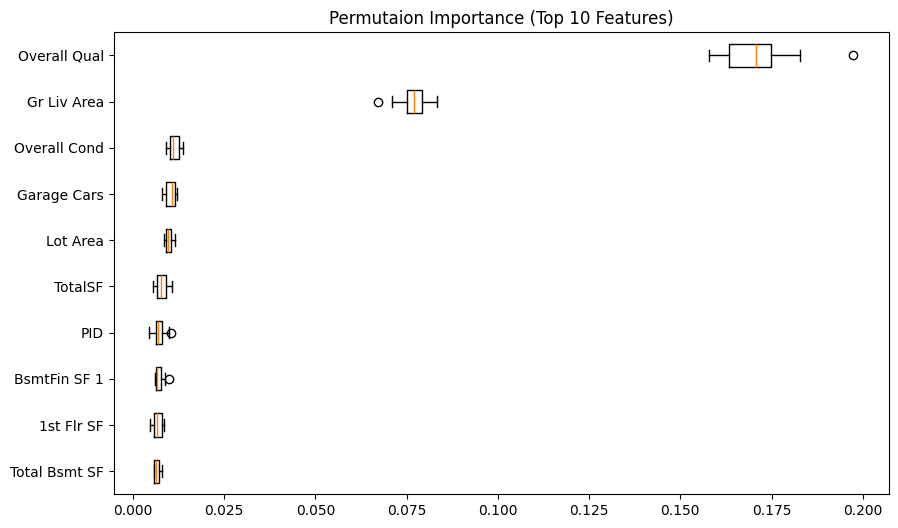

In [42]:
# Let's inspect the gradient Boosting component specifically to see what it learned

# Access the preprocessor
pre = full_pipeline.named_steps['preprocessor']

# Get Feature names after OneHotEncoding
# This is a bit technica: we need to reconstruct the names from the transformers
nom_names = pre.named_transformers_['nom']['encoder'].get_feature_names_out(nominal_cols)
all_feature_names = numerical_cols + ordinal_cols + list(nom_names)

# Accessing the HGB model inside the stack
# Path: Pipeline -> TransformedTargetRegressor -> StackingRegressor -> Estimators -> HGB
hgb_model = full_pipeline.named_steps['model'].regressor_.named_estimators_['hgb']

# Get Permutation Importance (HGB doesn't have feature_importances_ attribute directly in some versions,
#so permutation is safer and more model-agnostic)
from sklearn.inspection import permutation_importance
print("Calculating permutation Importance")
# NOTE : We must use the transformed X for inspection
X_test_transformed = pre.transform(X_test_clean)
result = permutation_importance(hgb_model, X_test_transformed, np.log1p(y_test), n_repeats=10, random_state=42, n_jobs=-1)

# Sort and plot
sorted_idx = result.importances_mean.argsort()[-10:] # Top 10
plt.figure(figsize=(10, 6))
plt.boxplot(result.importances[sorted_idx].T, vert=False,
            labels=np.array(all_feature_names)[sorted_idx])
plt.title("Permutaion Importance (Top 10 Features)")
plt.show()

**Saving the artifacts**

In [43]:
# We eed to save the model and the data processing logic (encapsulated in the pipeline)
# We also save the `clean_data` function logic implicitly by ensuring our production script uses it
model_filepath = 'house_price_model.joblib'
joblib.dump(full_pipeline, model_filepath)

print(f"Model saved {model_filepath}")

# Test loading
loaded_model = joblib.load(model_filepath)
sample_pred = loaded_model.predict(X_test_clean.iloc[:1])
print(f"Test load prediction: ${sample_pred[0]:,.2f}")

Model saved house_price_model.joblib
Test load prediction: $164,045.04


### Key Takeaways from `complete.ipynb`
1.  **Architecture**: We moved from a simple Random Forest to a **Stacked Ensemble** (Linear + Boosting). This captures both linear trends (Square Footage -> Price) and complex non-linear interactions.
2.  **Target Transformation**: The `TransformedTargetRegressor` is a professional tool. It ensures we never forget to inverse-transform our predictions.
3.  **Preprocessing**: We treated Ordinal data (Good/Bad) correctly, preserving the rank information that OneHotEncoding destroys.
4.  **Result**: The RMSLE should be significantly lower than the baseline, translating to thousands of dollars in improved accuracy.